In [14]:
import os
from contextlib import redirect_stdout
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import src.config as cfg
import src._1_data_prep as dp
import src._2_power_flow_optimization as pfo
from src._3_overall_cost import generer_bilan_financier


In [15]:
df_raw = dp.load_and_prepare_data()
df_raw

,private_MWh,price_EUR_MWh,business_MWh,CO2_g_MWh,t2m_C,radiation_solaire_factor,AMERA,SEVEN SEAS SPLENDOR,BALMORAL,SKY PRINCESS,...,VASCO DA GAMA,HAVILA POLARIS,NOORDERLICHT,IONA,JEWEL OF THE SEAS,SEVEN SEAS MARINER,AMADEA,CELEBRITY APEX,AIDASOL,SEABOURN VENTURE
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,0.202830,26.800000,0.945704,4730.0,0.75967,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 01:00:00,0.197758,32.800000,0.924756,4600.0,0.66458,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 02:00:00,0.192327,31.140000,0.927263,3920.0,0.58303,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 03:00:00,0.187711,32.800000,0.928286,3790.0,0.46475,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 04:00:00,0.186129,33.100000,0.963000,4050.0,0.43105,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,0.253905,10.000000,1.074408,7140.0,-1.55344,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-12-31 20:00:00,0.245642,11.100000,1.070172,6780.0,-1.50022,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-12-31 21:00:00,0.238986,14.900000,1.043138,7190.0,-1.51035,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
df_raw.columns

Index(['private_MWh', 'price_EUR_MWh', 'business_MWh', 'CO2_g_MWh', 't2m_C',
       'radiation_solaire_factor', 'AMERA', 'SEVEN SEAS SPLENDOR', 'BALMORAL',
       'SKY PRINCESS', 'DEUTSCHLAND', 'SERENADE OF THE SEAS', 'HAMBURG',
       'AIDAPRIMA', 'MIDNATSOL', 'CORINTHIAN', 'EUROPA 2', 'VIKING SATURN',
       'AZAMARA ONWARD', 'ROTTERDAM', 'COSTA DIADEMA', 'QUEEN MARY 2',
       'NORWEGIAN PRIMA', 'ZUIDERDAM', 'DISNEY DREAM', 'MARINA',
       'WORLD VOYAGER', 'LE CHAMPLAIN', 'CLIO', 'BOLETTE', 'COSTA FAVOLOSA',
       'MSC EURIBIA', 'STOCKHOLM', 'MEIN SCHIFF 3', 'AIDALUNA', 'SIRENA',
       'STAR PRIDE', 'AMBIENCE', 'MEIN SCHIFF 1', 'CELEBRITY SILHOUETTE',
       'RENAISSANCE', 'MEIN SCHIFF 4', 'MSC VIRTUOSA', 'AURORA', 'AIDAPERLA',
       'MEIN SCHIFF 7', 'EUROPA', 'LE COMMANDANT CHARCOT', 'HANSEATIC SPIRIT',
       'TROLLFJORD', 'SILVER DAWN', 'HEBRIDEAN SKY', 'QUEEN ANNE', 'AIDANOVA',
       'NORWEGIAN STAR', 'ANTHEM OF THE SEAS', 'AMBITION', 'ARCADIA',
       'MSC PREZIOSA', 'NIEU

In [17]:
df_sort=dp.sort_ship_columns(df_raw, start_idx=6, First_ship=0, Last_ship=70)

In [18]:
df_sort.columns[6:]

Index(['AIDANOVA', 'MSC EURIBIA', 'IONA', 'NORWEGIAN PRIMA', 'AIDAPRIMA',
       'AIDAPERLA', 'MEIN SCHIFF 4', 'COSTA DIADEMA', 'SKY PRINCESS',
       'BALMORAL', 'MEIN SCHIFF 3', 'MSC PREZIOSA', 'HAVILA POLARIS',
       'AIDASOL', 'QUEEN MARY 2', 'ARCADIA', 'MEIN SCHIFF 1',
       'CELEBRITY SILHOUETTE', 'ROTTERDAM', 'AURORA', 'COSTA FAVOLOSA',
       'BOLETTE', 'NIEUW STATENDAM', 'SILVER DAWN', 'MEIN SCHIFF 7',
       'VIKING VENUS', 'NORWEGIAN STAR', 'DISNEY DREAM', 'MSC VIRTUOSA',
       'SEVEN SEAS SPLENDOR', 'ANTHEM OF THE SEAS', 'RENAISSANCE',
       'JEWEL OF THE SEAS', 'SPIRIT OF DISCOVERY', 'TROLLFJORD', 'AMBITION',
       'BOREALIS', 'AMBIENCE', 'SERENADE OF THE SEAS', 'CELEBRITY APEX',
       'QUEEN ANNE', 'SIRENA', 'VASCO DA GAMA', 'AMERA', 'MARINA', 'AIDALUNA',
       'ZUIDERDAM', 'LE COMMANDANT CHARCOT', 'CLIO', 'EUROPA 2',
       'SEVEN SEAS MARINER', 'WORLD NAVIGATOR', 'LE CHAMPLAIN',
       'VIKING SATURN', 'STOCKHOLM', 'AZAMARA ONWARD', 'AMADEA',
       'SEVEN SEAS N

import os
from contextlib import redirect_stdout
import numpy as np
import pandas as pd
from tqdm import tqdm

import src.config as cfg
import src._1_data_prep as dp
import src._2_power_flow_optimization as pfo
from src._3_overall_cost import generer_bilan_financier

# 1. Définition des paramètres de l'étude
solar_capacities = list(range(1, 11)) # De 1 à 10 MW (pas de 1)
num_ships_list = list(range(0, 70))   # De 0 à 69 navires inclus

# 2. Chargement des données brutes et tri UNIQUE
print("Chargement des données brutes...")
df_raw = dp.load_and_prepare_data()

print("Tri des navires par consommation (une seule fois)...")
# On trie tous les navires (Last_ship=None par défaut ou on s'assure de tout prendre)
df_sorted = dp.sort_ship_columns(df_raw, start_idx=6)

results = []
total_iterations = len(solar_capacities) * len(num_ships_list)

print("="*50)
print(" Lancement de l'étude paramétrique")
print("="*50)

# 3. Double boucle avec barre de progression TQDM
with tqdm(total=total_iterations, desc="Simulations en cours") as pbar:
    for num_ships in num_ships_list:
        
        # Découpage ultra-rapide : les 6 colonnes de base + 'num_ships' colonnes de navires
        df_sim = df_sorted.iloc[:, :6 + num_ships].copy()
        
        for solar_cap in solar_capacities:
            # Mise à jour de la configuration
            cfg.SOLAR_CAPACITY_MW = solar_cap
            
            # Création du réseau PyPSA
            network = pfo.create_pypsa_network(df_sim, solar_cap, True)
            
            # Blocage des 'print' parasites de PyPSA
            with open(os.devnull, 'w') as f, redirect_stdout(f):
                status, condition = network.optimize()
                
                if status == "ok":
                    res = generer_bilan_financier(network)
                    bilan_net_k_eur = res["bilan"] / 1000  # k€
                else:
                    bilan_net_k_eur = np.nan
                    
            # Enregistrement du résultat
            results.append({
                "Taille PV (MW)": solar_cap,
                "Nombre de navires": num_ships,
                "Bilan Net (k€)": bilan_net_k_eur
            })
            
            pbar.update(1)

# 4. Sauvegarde dans un fichier CSV
df_results = pd.DataFrame(results)
df_results.to_csv("resultats_simulation.csv", index=False)
print("\nSimulations terminées. Résultats sauvegardés dans 'resultats_simulation.csv'.")

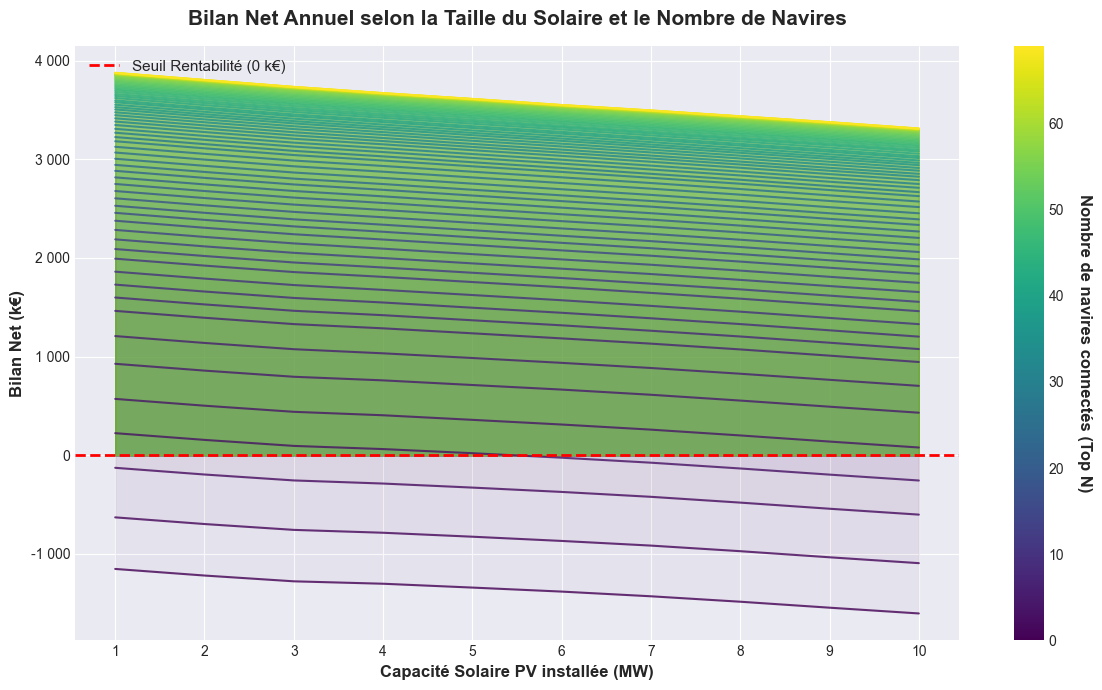

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# 1. Chargement des résultats
df_results = pd.read_csv("resultats_simulation.csv")

# 2. Préparation des variables pour le graphique
solar_capacities = df_results["Taille PV (MW)"].unique()
num_ships_list = df_results["Nombre de navires"].unique()

# ==========================================
# GÉNÉRATION DU GRAPHIQUE
# ==========================================
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Création d'une palette de couleurs continue (dégradé)
# 'viridis', 'plasma', ou 'coolwarm' rendent très bien pour ce type de variation
cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=min(num_ships_list), vmax=max(num_ships_list))

# Tracé des courbes
for num_ships in num_ships_list:
    df_plot = df_results[df_results["Nombre de navires"] == num_ships]
    
    # La couleur dépend du nombre de navires
    color = cmap(norm(num_ships))
    
    # On trace la ligne
    ax.plot(df_plot["Taille PV (MW)"], df_plot["Bilan Net (k€)"], 
            linewidth=1.5, color=color, alpha=0.8)
    
    # Remplissage très léger sous chaque courbe pour créer l'effet "zone de couleur"
    ax.fill_between(df_plot["Taille PV (MW)"], df_plot["Bilan Net (k€)"], 
                    color=color, alpha=0.03)

# Ligne d'équilibre (0 k€) bien visible
ax.axhline(0, color='red', linestyle='--', linewidth=2, label='Seuil Rentabilité (0 k€)')

# Esthétique générale
ax.set_title("Bilan Net Annuel selon la Taille du Solaire et le Nombre de Navires", 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Capacité Solaire PV installée (MW)", fontsize=12, fontweight='bold')
ax.set_ylabel("Bilan Net (k€)", fontsize=12, fontweight='bold')
ax.set_xticks(solar_capacities)

# Formatage de l'axe Y (séparateur de milliers)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(',', ' ')))

# Ajout d'une barre de couleur (Colorbar) au lieu d'une légende surchargée
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Nombre de navires connectés (Top N)", fontsize=12, fontweight='bold', rotation=270, labelpad=20)

# Légende classique uniquement pour le seuil de rentabilité
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig("bilan_gradient_navires.png", dpi=300, bbox_inches='tight')
plt.show()

In [20]:
df_results = pd.read_csv("resultats_simulation.csv")
df_results

,Taille PV (MW),Nombre de navires,Bilan Net (k€)
0,1,0,-1153.028352
1,2,0,-1219.940503
2,3,0,-1278.543030
3,4,0,-1303.027592
4,5,0,-1341.987434
...,...,...,...
695,6,69,3548.733248
696,7,69,3493.698276
697,8,69,3434.502672
698,9,69,3374.729236


/var/folders/_p/lntvskx96x323cvnklm36kvh0000gn/T/ipykernel_49710/2864312029.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("viridis", len(pivot.columns))


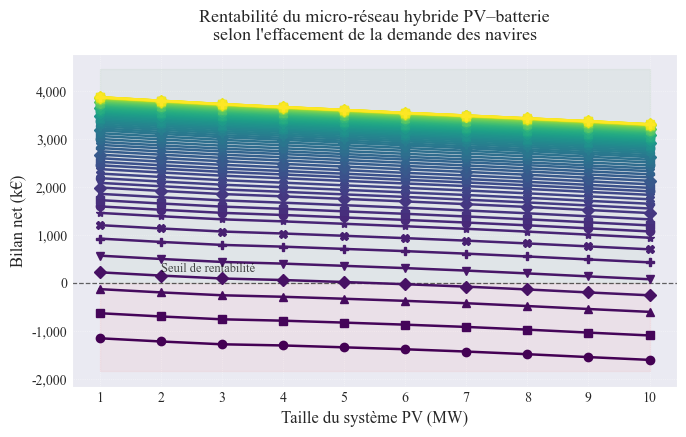

✓ Figure sauvegardée : rentabilite_microgrid.pdf / .png


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── 1. Données ────────────────────────────────────────────────────────────────
df_results = pd.read_csv("resultats_simulation.csv")

# Pivot : lignes = Taille PV, colonnes = Nombre de navires
pivot = df_results.pivot(
    index="Taille PV (MW)",
    columns="Nombre de navires",
    values="Bilan Net (k€)"
)

# ── 2. Style publication ───────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "font.size":        11,
    "axes.labelsize":   12,
    "axes.titlesize":   13,
    "legend.fontsize":  10,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "axes.linewidth":   0.8,
    "grid.linewidth":   0.5,
    "lines.linewidth":  1.8,
    "lines.markersize": 6,
})

# Palette colorblind-safe (ordonnée par nb navires croissant)
cmap   = plt.cm.get_cmap("viridis", len(pivot.columns))
colors = [cmap(i) for i in range(len(pivot.columns))]
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]

# ── 3. Figure ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

for idx, (n_ships, color) in enumerate(zip(pivot.columns, colors)):
    ax.plot(
        pivot.index,
        pivot[n_ships],
        color=color,
        marker=markers[idx % len(markers)],
        label=f"{n_ships} navire{'s' if n_ships > 1 else ''}",
        zorder=3,
    )

# Ligne de rentabilité nulle
ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.6, zorder=2)
ax.fill_between(pivot.index, 0, pivot.max().max() * 1.15,
                alpha=0.04, color="green", zorder=1)
ax.fill_between(pivot.index, pivot.min().min() * 1.15, 0,
                alpha=0.04, color="red", zorder=1)

# ── 4. Axes & annotations ──────────────────────────────────────────────────────
ax.set_xlabel("Taille du système PV (MW)")
ax.set_ylabel("Bilan net (k€)")
ax.set_title(
    "Rentabilité du micro-réseau hybride PV–batterie\n"
    "selon l'effacement de la demande des navires",
    pad=10,
)

ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(True, linestyle=":", alpha=0.6)
ax.set_axisbelow(True)

# Annotation seuil de rentabilité
ax.annotate(
    "Seuil de rentabilité",
    xy=(pivot.index[1], 0),
    xytext=(0, 8),
    textcoords="offset points",
    fontsize=9, color="black", alpha=0.7,
    ha="left",
)

# Légende


# ── 5. Export ──────────────────────────────────────────────────────────────────
fig.tight_layout()
fig.savefig("rentabilite_microgrid.pdf", dpi=300, bbox_inches="tight")
fig.savefig("rentabilite_microgrid.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Figure sauvegardée : rentabilite_microgrid.pdf / .png")

In [22]:
import src._1_data_prep
import src._2_power_flow_optimization as pfo
import src._3_overall_cost
import src.config as cfg

df = dp.sort_ship_columns(dp.load_and_prepare_data())
df

,private_MWh,price_EUR_MWh,business_MWh,CO2_g_MWh,t2m_C,radiation_solaire_factor,AIDANOVA,MSC EURIBIA,IONA,NORWEGIAN PRIMA,...,EUROPA,SEABOURN VENTURE,STAR PRIDE,DEUTSCHLAND,HAMBURG,CORINTHIAN,WORLD VOYAGER,HANSEATIC SPIRIT,HEBRIDEAN SKY,NOORDERLICHT
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,0.202830,26.800000,0.945704,4730.0,0.75967,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 01:00:00,0.197758,32.800000,0.924756,4600.0,0.66458,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 02:00:00,0.192327,31.140000,0.927263,3920.0,0.58303,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 03:00:00,0.187711,32.800000,0.928286,3790.0,0.46475,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 04:00:00,0.186129,33.100000,0.963000,4050.0,0.43105,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,0.253905,10.000000,1.074408,7140.0,-1.55344,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-12-31 20:00:00,0.245642,11.100000,1.070172,6780.0,-1.50022,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-12-31 21:00:00,0.238986,14.900000,1.043138,7190.0,-1.51035,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
network = pfo.create_pypsa_network(df, cfg.SOLAR_CAPACITY_MW, Battery=True)
network

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 4
 - Carrier: 6
 - Generator: 2
 - Link: 5
 - Load: 71
 - StorageUnit: 1
Snapshots: 8784

In [24]:
status, condition = network.optimize()

/var/folders/_p/lntvskx96x323cvnklm36kvh0000gn/T/ipykernel_49710/491637259.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status, condition = network.optimize()
Index(['bus_main', 'bus_ship', 'bus_solar', 'bus_battery'], dtype='str', name='name')
Index(['link_shore_power', 'link_solar_main', 'link_battery_to_main',
       'link_main_to_battery', 'link_solar_to_battery'],
      dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 760.80it/s]
INFO:linopy.io: Writing time: 0.14s


Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-hpknb0bd has 219600 rows; 87840 cols; 333791 nonzeros
Coefficient ranges:
  Matrix  [9e-01, 1e+00]
  Cost    [1e-02, 2e+02]
  Bound   [0e+00, 0e+00]
  RHS     [2e-04, 1e+06]
Presolving model
31123 rows, 67017 cols, 120478 nonzeros  0s
27110 rows, 54220 cols, 94884 nonzeros  0s
Dependent equations search running on 22283 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
22283 rows, 49393 cols, 85174 nonzeros  0s
Presolve reductions: rows 22283(-197317); columns 49393(-38447); nonzeros 85174(-248617) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.1s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 87840 primals, 219600 duals
Objective: 2.10e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


      32329     2.1014184842e+06 Pr: 0(0); Du: 0(1.2701e-13) 0.4s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-hpknb0bd
Model status        : Optimal
Simplex   iterations: 32329
Objective value     :  2.1014184842e+06
P-D objective error :  3.1023123287e-15
HiGHS run time      :          0.40


In [25]:
resultats_financiers = generer_bilan_financier(network)
resultats_financiers

 BILAN FINANCIER ANNUEL DE LA MUNICIPALITÉ 

[DÉPENSES]
  Facture énergétique (Business) : 603,213.95 €
  Facture énergétique (Private)  : 93,851.62 €
  Facture énergétique (Ship)     : 1,899,841.41 €
  CAPEX + OPEX Solaire           : 745,886.76 €
  CAPEX + OPEX Batterie          : 298,921.61 €
----------------------------------------
  TOTAL DÉPENSES                 : 3,641,715.34 €

[REVENUS]
  Vente énergie navires (SP)     : 6,952,148.04 €
----------------------------------------

[BILAN]
  PROFIT                         : +3,310,432.70 €


{'depenses_energie': np.float64(2596906.9773199996),
 'depenses_solaire': np.float64(745886.75925),
 'depenses_stockage': np.float64(298921.60728),
 'total_depenses': np.float64(3641715.34385),
 'revenu_sp': np.float64(6952148.040003732),
 'bilan': np.float64(3310432.696153732)}

In [26]:
network.statistics()

Optimal Capacity  Installed Capacity       Supply  \
Generator   Grid             1000000.0           1000000.0  26221.84472   
            Solar                 10.0                10.0   7301.35479   
Link        AC               5000000.0           5000000.0      0.00000   
Load        Business               0.0                 0.0      0.00000   
            Private                0.0                 0.0      0.00000   
            Ship                   0.0                 0.0      0.00000   
StorageUnit Battery                8.0                 8.0    952.74345   

                       Withdrawal  Energy Balance  Transmission  \
Generator   Grid          0.00000     26221.84472       0.00000   
            Solar         0.00000      7301.35479       0.00000   
Link        AC        37855.50161    -37855.50161   37855.50161   
Load        Business   8693.28015     -8693.28015       0.00000   
            Private    1340.77826     -1340.77826       0.00000   
            Ship      20877.32144    -20877.32144       0.00000   
StorageUnit Battery    1244.86071      -292.11727       0.00000   

                      Capacity Factor   Curtailment  Capital Expenditure  \
Generator   Grid         2.985180e-06  8.783974e+09              0.00000   
            Solar        8.312100e-02  1.149116e+03         745813.74570   
Link        AC           8.619200e-07  0.000000e+00              0.00000   
Load        Business              NaN  0.000000e+00              0.00000   
            Private               NaN  0.000000e+00              0.00000   
            Ship                  NaN  0.000000e+00              0.00000   
StorageUnit Battery      3.127250e-02  7.056412e+04         295110.63349   

                      Operational Expenditure       Revenue  Market Value  
Generator   Grid                 2.097534e+06  2.097534e+06     79.991947  
            Solar                7.301355e+01  4.478871e+05     61.343066  
Link        AC                   0.000000e+00 -2.871717e+06           NaN  
Load        Business             0.000000e+00 -6.032139e+05           NaN  
            Private              0.000000e+00 -9.385162e+04           NaN  
            Ship                 0.000000e+00 -1.899841e+06           NaN  
StorageUnit Battery              3.810974e+03  5.148538e+04     54.040845